# Director Analysis for Movie Ratings (Improved)

This notebook analyzes how directors impact movie ratings by calculating director scores based on their popularity (average ratings) and experience (number of movies directed).

## 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load and Prepare the Data

We'll load data from three IMDb datasets:
- title.ratings.tsv.gz - contains movie ratings
- title.crew.tsv.gz - contains director information
- title.basics.tsv.gz - contains basic movie information
- name.basics.tsv.gz - contains director names

In [4]:
# Load ratings data
print("Loading ratings data...")
ratings_df = pd.read_csv(
    'title.ratings.tsv.gz',
    sep='\t',
    usecols=['tconst', 'averageRating', 'numVotes']
)
print(f"Loaded {len(ratings_df)} rating records")

# Load crew data with directors
print("Loading crew data...")
crew_df = pd.read_csv(
    'title.crew.tsv.gz',
    sep='\t',
    usecols=['tconst', 'directors'],
    na_values='\\N'
)
print(f"Loaded {len(crew_df)} crew records")

# Load basic title information
print("Loading basic title data...")
basics_df = pd.read_csv(
    'title.basics.tsv.gz',
    sep='\t',
    usecols=['tconst', 'titleType', 'startYear', 'primaryTitle'],
    na_values='\\N'
)
print(f"Loaded {len(basics_df)} basic records")

# Load director name information
print("Loading director name data...")
names_df = pd.read_csv(
    'name.basics.tsv.gz',
    sep='\t',
    usecols=['nconst', 'primaryName'],
    na_values='\\N'
)
print(f"Loaded {len(names_df)} name records")

Loading ratings data...
Loaded 1564716 rating records
Loading crew data...
Loaded 11637194 crew records
Loading basic title data...
Loaded 11635190 basic records
Loading director name data...
Loaded 14381212 name records


## 3. Filter for Movies and Merge Datasets

In [5]:
# Filter for movies only
movies_df = basics_df[basics_df['titleType'] == 'movie'].copy()
print(f"Found {len(movies_df)} movies in the dataset")

# Merge the datasets
merged_df = (movies_df
    .merge(crew_df, on='tconst', how='inner')
    .merge(ratings_df, on='tconst', how='inner')
)

print(f"Working with {len(merged_df)} movies after merging")

Found 713837 movies in the dataset
Working with 329531 movies after merging


## 4. Handle Missing Data

Let's identify missing values and implement an appropriate imputation strategy.

In [6]:
# Check for missing values
missing_data = {
    'directors': merged_df['directors'].isna().sum(),
    'averageRating': merged_df['averageRating'].isna().sum(),
    'startYear': merged_df['startYear'].isna().sum()
}
print(f"Missing data counts: {missing_data}")

# Imputation strategy: Remove rows with missing directors
merged_df = merged_df.dropna(subset=['directors'])
print(f"After removing rows with missing directors: {len(merged_df)} movies")

# Handle potential missing startYear values (impute with median)
if merged_df['startYear'].isna().sum() > 0:
    median_year = merged_df['startYear'].median()
    merged_df['startYear'] = merged_df['startYear'].fillna(median_year)
    print(f"Imputed {missing_data['startYear']} missing years with median: {median_year}")

Missing data counts: {'directors': 4094, 'averageRating': 0, 'startYear': 33}
After removing rows with missing directors: 325437 movies
Imputed 33 missing years with median: 2007.0


## 5. Process Director Information

We'll create director-movie pairs to analyze director performance across all their movies.

In [7]:
# Process directors data (splitting comma-separated director IDs)
merged_df['directors'] = merged_df['directors'].fillna('')
director_movie_pairs = []

for _, row in merged_df.iterrows():
    if row['directors'] and row['directors'] != '\\N':
        director_list = row['directors'].split(',')
        for director in director_list:
            if director:
                director_movie_pairs.append({
                    'tconst': row['tconst'],
                    'director': director,
                    'primaryTitle': row['primaryTitle'],
                    'startYear': row['startYear'],
                    'averageRating': row['averageRating'],
                    'numVotes': row['numVotes']
                })

# Create DataFrame from pairs
director_movie_df = pd.DataFrame(director_movie_pairs)
print(f"Created {len(director_movie_df)} director-movie pairs")

Created 371406 director-movie pairs


## 6. Calculate Director Metrics

In [8]:
# Calculate director metrics
director_stats = director_movie_df.groupby('director').agg(
    avg_rating=('averageRating', 'mean'),
    movie_count=('tconst', 'count'),
    total_votes=('numVotes', 'sum')
).reset_index()

print(f"Generated stats for {len(director_stats)} directors")

# Add director names
director_stats = director_stats.merge(names_df, left_on='director', right_on='nconst', how='left')
director_stats.rename(columns={'primaryName': 'director_name'}, inplace=True)
director_stats.drop('nconst', axis=1, inplace=True)

# Check how many directors we could match with names
name_match_count = director_stats['director_name'].notna().sum()
print(f"Successfully matched {name_match_count} directors with their names ({name_match_count/len(director_stats)*100:.1f}%)")

# Show a sample of directors with their names
director_stats.head(10)

Generated stats for 146578 directors
Successfully matched 146578 directors with their names (100.0%)


,director,avg_rating,movie_count,total_votes,director_name
0,nm0000005,7.214286,42,916566,Ingmar Bergman
1,nm0000008,7.100000,1,14259,Marlon Brando
2,nm0000009,5.400000,1,1422,Richard Burton
3,nm0000010,6.000000,1,443,James Cagney
4,nm0000018,5.800000,2,2996,Kirk Douglas
5,nm0000019,7.191667,24,530681,Federico Fellini
6,nm0000024,7.600000,1,547,John Gielgud
7,nm0000032,5.750000,2,3102,Charlton Heston
8,nm0000033,6.851852,54,4114195,Alfred Hitchcock
9,nm0000036,7.240000,15,257348,Buster Keaton


## 7. Analyze Correlation between Experience and Popularity

In [9]:
# Calculate correlation between experience and rating
r, p_value = pearsonr(director_stats['movie_count'], director_stats['avg_rating'])
print(f"Correlation between director experience and popularity: r={r:.3f} (p={p_value:.3g})")

Correlation between director experience and popularity: r=-0.055 (p=1.21e-99)


## 8. Calculate Director Scores

We'll create a composite score for each director based on:
- 70% weighted on popularity (average rating)
- 30% weighted on experience (number of movies directed)

In [10]:
# Calculate normalized metrics and final score
director_stats['popularity'] = (director_stats['avg_rating'] - director_stats['avg_rating'].min()) / (director_stats['avg_rating'].max() - director_stats['avg_rating'].min())
director_stats['experience'] = np.log1p(director_stats['movie_count']) / np.log1p(director_stats['movie_count'].max())
director_stats['director_score'] = 0.7 * director_stats['popularity'] + 0.3 * director_stats['experience']

# Show top directors by overall score
top_directors = director_stats.sort_values('director_score', ascending=False).head(10)
print("Top 10 directors by overall score:")
top_directors[['director', 'director_name', 'avg_rating', 'movie_count', 'director_score']]

Top 10 directors by overall score:


,director,director_name,avg_rating,movie_count,director_score
50154,nm1100866,Dylan Verrechia,8.978125,32,0.817222
13045,nm0269807,Sibtain Fazli,9.026667,15,0.780272
17395,nm0368257,S.F. Hasnain,9.025000,12,0.768462
62846,nm13498791,Prince Oak Oakleyski,8.900000,14,0.766790
40327,nm0891320,René Vautier,8.421429,28,0.766654
57283,nm12334780,I. Kolyada,9.054545,11,0.766257
45541,nm1024715,Alonso O. Lara,8.279412,34,0.766188
66053,nm1425932,Ismael Rubio,9.500000,5,0.761909
141611,nm8887892,Simran S Kaler,9.383333,6,0.761507
65719,nm14175849,Victor Schiavon,9.575000,4,0.757486


## 9. Visualization: Popularity vs. Experience

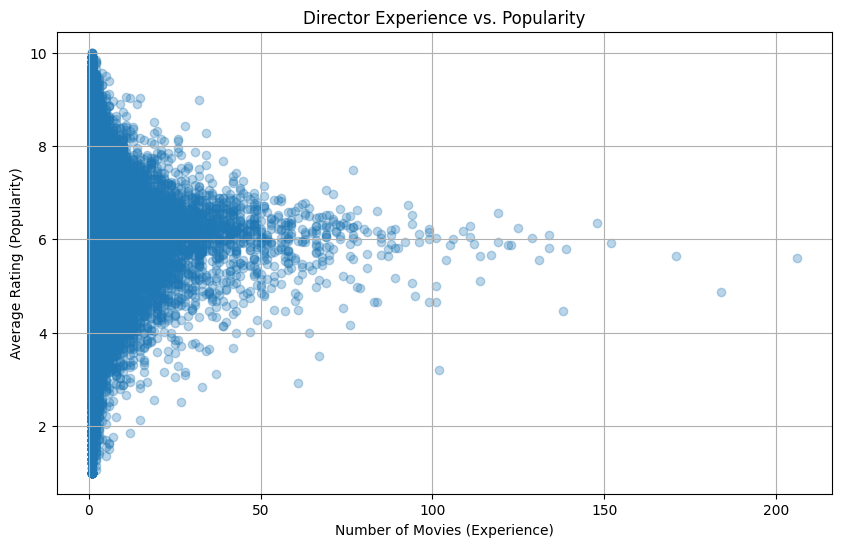

In [11]:
# Create visual: Popularity vs. Experience
plt.figure(figsize=(10, 6))
plt.scatter(director_stats['movie_count'], director_stats['avg_rating'], alpha=0.3)
plt.xlabel('Number of Movies (Experience)')
plt.ylabel('Average Rating (Popularity)')
plt.title('Director Experience vs. Popularity')
plt.grid(True)
plt.savefig('director_experience_vs_popularity.png')
plt.show()

## 10. Apply Director Scores to Movies

In [12]:
# Create a director score lookup dictionary
director_scores = dict(zip(director_stats['director'], director_stats['director_score']))

# Function to calculate a movie's director score
def get_director_score(directors_str):
    if not directors_str or directors_str == '\\N':
        return np.nan
    
    directors = directors_str.split(',')
    scores = [director_scores.get(d, 0) for d in directors if d in director_scores]
    if not scores:
        return 0
    return np.mean(scores)

# Apply to merged dataframe
merged_df['director_score'] = merged_df['directors'].apply(get_director_score)

## 11. Visualization: Director Score vs. Movie Rating

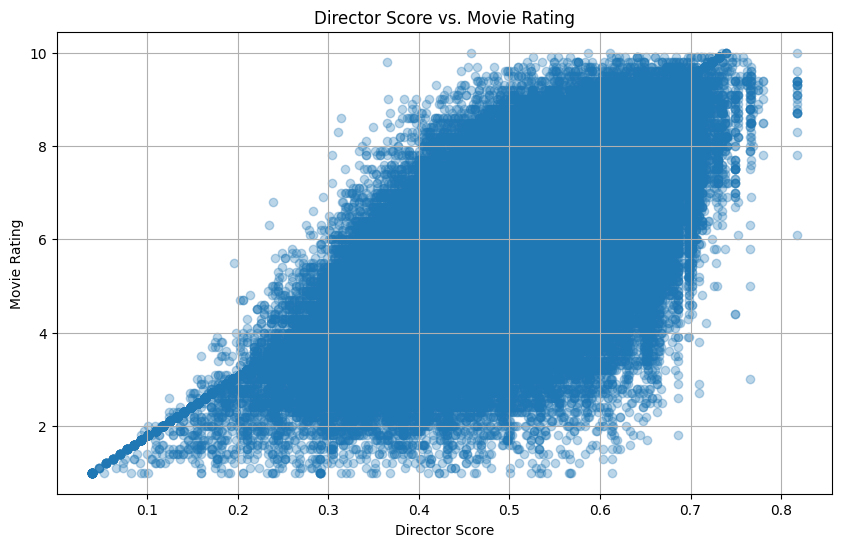

Correlation between director score and movie rating: r=0.660 (p=0)
R-squared value: 0.435 - This means director scores explain 43.5% of the variance in movie ratings


In [13]:
# Create visual: Director Score vs. Movie Rating
plt.figure(figsize=(10, 6))
plt.scatter(merged_df['director_score'], merged_df['averageRating'], alpha=0.3)
plt.xlabel('Director Score')
plt.ylabel('Movie Rating')
plt.title('Director Score vs. Movie Rating')
plt.grid(True)
plt.savefig('director_score_vs_rating.png')
plt.show()

# Calculate correlation between director score and movie rating
r_score, p_value_score = pearsonr(merged_df['director_score'], merged_df['averageRating'])
print(f"Correlation between director score and movie rating: r={r_score:.3f} (p={p_value_score:.3g})")

# Calculate R-squared value
r_squared = r_score ** 2
print(f"R-squared value: {r_squared:.3f} - This means director scores explain {r_squared*100:.1f}% of the variance in movie ratings")

## 12. Additional Visualization: Director Distribution Heatmap

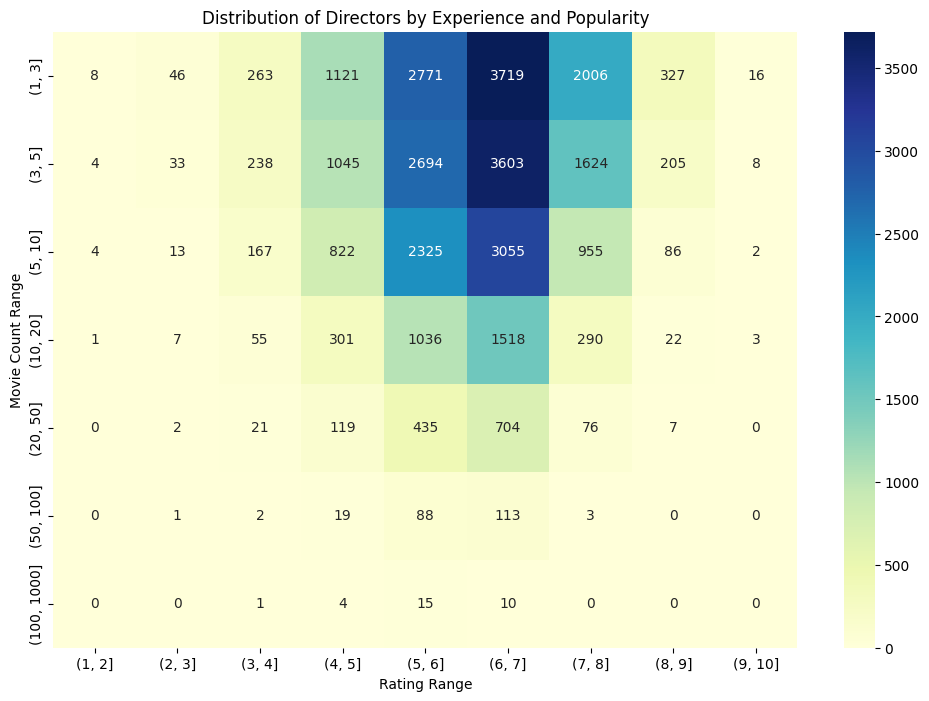

In [14]:
# Filter to directors with at least 3 movies for more reliable stats
experienced_directors = director_stats[director_stats['movie_count'] >= 3].copy()

# Create ranges for experience and popularity
exp_bins = [1, 3, 5, 10, 20, 50, 100, 1000]
pop_bins = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

experienced_directors['exp_bin'] = pd.cut(experienced_directors['movie_count'], bins=exp_bins)
experienced_directors['pop_bin'] = pd.cut(experienced_directors['avg_rating'], bins=pop_bins)

# Create a pivot table for the heatmap
heatmap_data = pd.crosstab(experienced_directors['exp_bin'], experienced_directors['pop_bin'])

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt='d')
plt.title('Distribution of Directors by Experience and Popularity')
plt.xlabel('Rating Range')
plt.ylabel('Movie Count Range')
plt.savefig('director_experience_popularity_heatmap.png')
plt.show()

## 13. Create a Regression Model to Predict Ratings from Director Scores

This will help us quantify the explanatory power of director scores more precisely.

Model Performance:
Mean Squared Error (MSE): 1.0751
Root Mean Squared Error (RMSE): 1.0369
R-squared: 0.4351
Director scores alone explain 43.51% of the variance in movie ratings


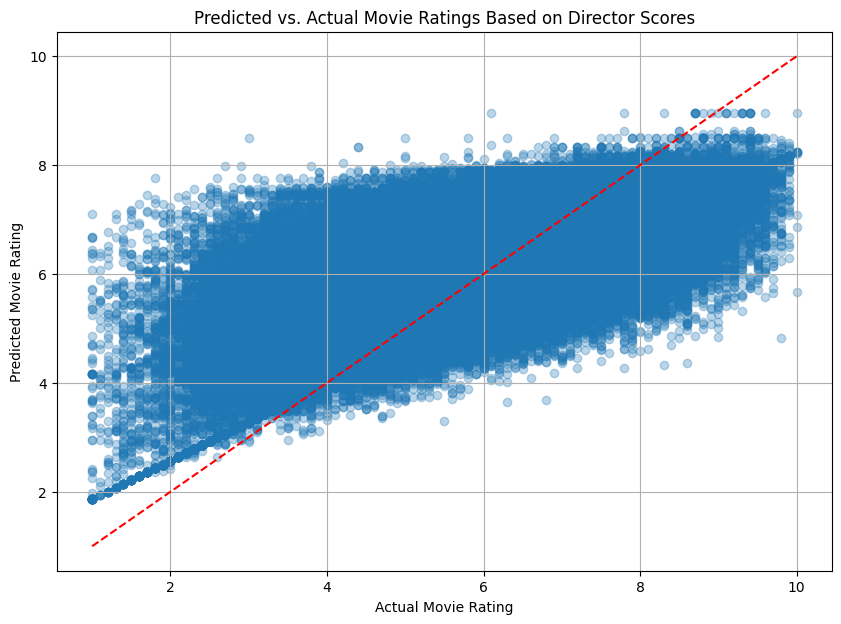

In [15]:
# Prepare data for modeling
model_data = merged_df[['director_score', 'averageRating']].dropna()
X = model_data[['director_score']]
y = model_data['averageRating']

# Create and fit a Ridge regression model
model = Ridge(alpha=1.0)
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print(f"Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Director scores alone explain {r2*100:.2f}% of the variance in movie ratings")

# Plot actual vs predicted values
plt.figure(figsize=(10, 7))
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual Movie Rating')
plt.ylabel('Predicted Movie Rating')
plt.title('Predicted vs. Actual Movie Ratings Based on Director Scores')
plt.grid(True)
plt.savefig('director_rating_prediction.png')
plt.show()

## 14. Create Final Dataset with Director Scores and Names

In [16]:
# Function to get director names
director_names = dict(zip(names_df['nconst'], names_df['primaryName']))

def get_director_names(directors_str):
    if not directors_str or directors_str == '\\N':
        return ''
    
    directors = directors_str.split(',')
    names = [director_names.get(d, d) for d in directors]
    return ', '.join(names)

# Add director names to merged dataframe
merged_df['director_names'] = merged_df['directors'].apply(get_director_names)

# Create and save the final clean CSV with all director analysis
final_csv = merged_df[['tconst', 'primaryTitle', 'startYear', 'directors', 'director_names', 'averageRating', 'numVotes', 'director_score']]
final_csv.to_csv('directors_analysis_complete.csv', index=False)
print(f"Successfully created directors_analysis_complete.csv with {len(final_csv)} rows")

# Show the first few rows
final_csv.head()

Successfully created directors_analysis_complete.csv with 325437 rows


,tconst,primaryTitle,startYear,directors,director_names,averageRating,numVotes,director_score
0,tt0000009,Miss Jerry,1894.0,nm0085156,Alexander Black,5.4,223,0.381216
1,tt0000147,The Corbett-Fitzsimmons Fight,1897.0,nm0714557,Enoch J. Rector,5.3,558,0.357360
2,tt0000502,Bohemios,1905.0,nm0063413,Ricardo de Baños,3.8,21,0.389470
3,tt0000574,The Story of the Kelly Gang,1906.0,nm0846879,Charles Tait,6.0,985,0.427883
4,tt0000591,The Prodigal Son,1907.0,nm0141150,Michel Carré,5.6,31,0.404026


## 15. Summary of Findings

In [17]:
print("\n=== ANALYSIS SUMMARY ===")
print("Data Cleaning Strategy:")
print("1. Removed rows with missing director information (essential for analysis)")
print("2. Filled missing release years with median value (if any)")
print(f"3. Analyzed {len(director_stats)} directors across {len(merged_df)} movies")
print("\nFindings:")
print(f"- Director experience vs. popularity correlation: r={r:.3f} (p={p_value:.3g})")
print(f"- Director score vs. movie rating correlation: r={r_score:.3f} (p={p_value_score:.3g})")
print(f"- R-squared from regression model: {r2:.4f} - Director scores explain {r2*100:.2f}% of variance in ratings")
print("- See generated visualizations for detailed relationship patterns")
print("\nDirector Score Formula:")
print("- 70% weighted on normalized popularity (average rating)")
print("- 30% weighted on normalized experience (log-transformed movie count)")
print("This balances quality of work with industry experience")

print("\nTop 5 Directors by Score:")
for _, row in director_stats.sort_values('director_score', ascending=False).head(5).iterrows():
    name = row['director_name'] if not pd.isna(row['director_name']) else row['director']
    print(f"  {name}: score={row['director_score']:.3f}, avg_rating={row['avg_rating']:.2f}, movies={row['movie_count']}")


=== ANALYSIS SUMMARY ===
Data Cleaning Strategy:
1. Removed rows with missing director information (essential for analysis)
2. Filled missing release years with median value (if any)
3. Analyzed 146578 directors across 325437 movies

Findings:
- Director experience vs. popularity correlation: r=-0.055 (p=1.21e-99)
- Director score vs. movie rating correlation: r=0.660 (p=0)
- R-squared from regression model: 0.4351 - Director scores explain 43.51% of variance in ratings
- See generated visualizations for detailed relationship patterns

Director Score Formula:
- 70% weighted on normalized popularity (average rating)
- 30% weighted on normalized experience (log-transformed movie count)
This balances quality of work with industry experience

Top 5 Directors by Score:
  Dylan Verrechia: score=0.817, avg_rating=8.98, movies=32
  Sibtain Fazli: score=0.780, avg_rating=9.03, movies=15
  S.F. Hasnain: score=0.768, avg_rating=9.03, movies=12
  Prince Oak Oakleyski: score=0.767, avg_rating=8.90

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.regularizers import l2
import time
import pickle
import os

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Loading data...")
# Load the prepared director data
df = pd.read_csv('directors_analysis_complete.csv')

# Select features and target variable
features = ['director_score']
target = 'averageRating'

# Prepare X and y
X = df[features].values
y = df[target].values

# Split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define parameters to test - using a minimal subset for quick execution
batch_sizes = [32, 64]
hidden_nodes = [32, 64, 128]
learning_rates = [0.01]  # Just using one learning rate for speed
activations = ['relu']    # Just using one activation for speed
momentums = [0.9]        # Just using one momentum for speed
reg_params = [0.001]     # Just using one reg param for speed

# To store results
results = []

# Define the model creation function
def create_model(hidden_nodes, activation, learning_rate, momentum, reg_param):
    model = Sequential([
        Dense(hidden_nodes, activation=activation, kernel_regularizer=l2(reg_param), 
              input_shape=(X_train.shape[1],)),
        Dense(1)  # Output layer for regression
    ])
    
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(loss='mse', optimizer=optimizer)
    return model

# Test each combination
total_combinations = len(batch_sizes) * len(hidden_nodes) * len(learning_rates) * len(activations) * len(momentums) * len(reg_params)
print(f"Testing {total_combinations} parameter combinations")

counter = 0
for batch_size in batch_sizes:
    for nodes in hidden_nodes:
        for lr in learning_rates:
            for activation in activations:
                for momentum in momentums:
                    for reg_param in reg_params:
                        counter += 1
                        print(f"Configuration {counter}/{total_combinations}: batch={batch_size}, nodes={nodes}")
                        
                        # Create and train model
                        model = create_model(nodes, activation, lr, momentum, reg_param)
                        
                        # Train for a fixed number of epochs - keeping it small for speed
                        start_time = time.time()
                        model.fit(
                            X_train_scaled, y_train,
                            batch_size=batch_size,
                            epochs=20,  # Reduced epochs for speed
                            verbose=0
                        )
                        training_time = time.time() - start_time
                        
                        # Evaluate model
                        y_pred = model.predict(X_test_scaled, verbose=0)
                        mse = mean_squared_error(y_test, y_pred)
                        r2 = r2_score(y_test, y_pred)
                        
                        # Store results
                        results.append({
                            'batch_size': batch_size,
                            'hidden_nodes': nodes,
                            'learning_rate': lr,
                            'activation': activation,
                            'momentum': momentum,
                            'reg_param': reg_param,
                            'mse': mse,
                            'r2': r2,
                            'training_time': training_time
                        })
                        
                        print(f"  MSE: {mse:.4f}, R²: {r2:.4f}, Time: {training_time:.2f}s")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Find the best model
best_model = results_df.loc[results_df['r2'].idxmax()]
print("\nBest model configuration:")
print(best_model)

# Save results
results_df.to_csv('ann_hyperparameter_results.csv', index=False)
print("Results saved to 'ann_hyperparameter_results.csv'")

# Create output directory if it doesn't exist
os.makedirs('results', exist_ok=True)

# Save the scaler for potential future use
with open('results/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Train final model with best parameters
print("\nTraining final model with best parameters...")
final_model = create_model(
    int(best_model['hidden_nodes']),
    best_model['activation'],
    best_model['learning_rate'],
    best_model['momentum'],
    best_model['reg_param']
)

final_model.fit(
    X_train_scaled, y_train,
    batch_size=int(best_model['batch_size']),
    epochs=50,  # More epochs for the final model
    verbose=1
)

# Evaluate final model
final_y_pred = final_model.predict(X_test_scaled, verbose=0)
final_mse = mean_squared_error(y_test, final_y_pred)
final_r2 = r2_score(y_test, final_y_pred)

print(f"\nFinal model performance:")
print(f"MSE: {final_mse:.4f}")
print(f"R²: {final_r2:.4f}")

# Save final results with hyperparameters in CSV format
final_results = {
    'batch_size': [int(best_model['batch_size'])],
    'hidden_nodes': [int(best_model['hidden_nodes'])], 
    'learning_rate': [best_model['learning_rate']],
    'activation': [best_model['activation']],
    'momentum': [best_model['momentum']],
    'reg_param': [best_model['reg_param']],
    'final_mse': [final_mse],
    'final_r2': [final_r2]
}

pd.DataFrame(final_results).to_csv('results/best_model_performance.csv', index=False)
print("Best model performance saved to 'results/best_model_performance.csv'")

# If you still want to save the model weights for future use
# Save weights dictionary as JSON
model_weights = []
for layer in final_model.layers:
    layer_weights = layer.get_weights()
    model_weights.append([w.tolist() for w in layer_weights])

import json
with open('results/model_weights.json', 'w') as f:
    json.dump(model_weights, f)

print("Analysis complete. All results saved in the 'results' directory.")

Loading data...
Testing 6 parameter combinations
Configuration 1/6: batch=32, nodes=32


c:\Users\safwa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  MSE: 1.0899, R²: 0.4262, Time: 176.61s
Configuration 2/6: batch=32, nodes=64


c:\Users\safwa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  MSE: 1.0889, R²: 0.4267, Time: 259.28s
Configuration 3/6: batch=32, nodes=128


...

  MSE: 1.0722, R²: 0.4355, Time: 123.26s
Configuration 6/6: batch=64, nodes=128


c:\Users\safwa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  MSE: 1.0727, R²: 0.4353, Time: 126.21s

Best model configuration:
batch_size               64
hidden_nodes             32
learning_rate          0.01
activation             relu
momentum                0.9
reg_param             0.001
mse                1.072017
r2                 0.435597
training_time    132.731421
Name: 3, dtype: object
Results saved to 'ann_hyperparameter_results.csv'

Training final model with best parameters...
Epoch 1/50


c:\Users\safwa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4068/4068 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.4821
Epoch 2/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0643
Epoch 3/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0641
Epoch 4/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0616
Epoch 5/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 6/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 7/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 8/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 9/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 10/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0605
Epoch 11/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1.0604
Epoch 12/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0605
Epoch 13/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 14/50
4068/4068 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.0604
Epoch 15/50
4068/4068 ━━━━━━━━━━━━━━━━━━